# Steam Game Recommendation Chatbot

This notebook covers end-to-end dataset preparation, feature extraction, entity recognition, intent classification modeling (Logistic Regression vs. LinearSVC), and NLP metric evaluation.

## 1. Setup and Imports

In [1]:
import json
import os
import re
import sys
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from flashtext import KeywordProcessor
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from rouge_score import rouge_scorer
from scipy.sparse import save_npz
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC


### 1.1 Helper Functions

In [2]:
# Text processing
def clean_text(text):
    text = str(text).casefold()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    text = re.sub(r"[']", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def process_metadata(val):
    if isinstance(val, dict):
        raw_list = list(val.keys())
    elif isinstance(val, list):
        raw_list = val
    else:
        return []
    return [clean_text(item) for item in raw_list if str(item).strip()]


def wilson_score(positive, total, z=1.96):
    p = np.divide(
        positive, total, out=np.zeros_like(positive, dtype=float), where=total > 0
    )

    denominator = 1 + z**2 / total
    centre = p + z**2 / (2 * total)

    adjustment = z * np.sqrt((p * (1 - p) / total) + (z**2 / (4 * total**2)))

    score = (centre - adjustment) / denominator

    return np.where(total > 0, score, 0.0)

## 1.2 Configuration & Paths

In [3]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR", "./data"))
MODELS_DIR = Path(os.getenv("MODELS_DIR", "./models"))

GAMES_PATH = Path(os.getenv("GAMES_PATH",  str(DATA_DIR / "games.json")))
INTENTS_PATH = DATA_DIR / "intents.json"
EVAL_BLEU_PATH = DATA_DIR / "eval_bleu.json"
EVAL_ROUGE_PATH = DATA_DIR / "eval_rouge.json"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(DATA_DIR))

## 2. Dataset Preparation

### 2.1 Load Dataset

In [4]:
df_original = pd.read_json(GAMES_PATH, orient="index")
df_original.index.name = "app_id"

print(df_original.dtypes)
print(df_original.shape)

name                            str
release_date                    str
required_age                  int64
price                       float64
dlc_count                     int64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
metacritic_url                  str
achievements                  int64
recommendations               int64
notes                           str
supported_languages          object
full_audio_languages         object
packages                     object
developers                   object
publishers                   object
categories                   object
genres                      

### 2.2 Basic Data Cleaning & Deduplication

In [5]:
df = df_original.reset_index()

df["name"] = df["name"].str.strip()
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# Remove incomplete metadata rows
df = df[df["name"].notna() & df["name"].ne("")]

metadata_columns = ["categories", "genres", "tags"]

has_metadata = (
    df[metadata_columns]
    .apply(lambda col: col.map(lambda x: isinstance(x, (list, dict)) and len(x) > 0))
    .any(axis=1)
)

df = df[has_metadata]

# Deduplicate rows
dedup_keys = ["name", "release_date", "detailed_description"]

df["null_count"] = df.isnull().sum(axis=1)

df = (
    df.sort_values(by=["null_count", "app_id"], ascending=[True, True])
    .drop_duplicates(subset=dedup_keys, keep="first")
    .drop(columns=["null_count"])
    .reset_index(drop=True)
)

# Drop unnecessary columns
columns_to_drop = [
    "required_age",
    "dlc_count",
    "detailed_description",
    "about_the_game",
    "reviews",
    "header_image",
    "website",
    "support_url",
    "support_email",
    "metacritic_url",
    "achievements",
    "notes",
    "supported_languages",
    "full_audio_languages",
    "packages",
    "screenshots",
    "movies",
    "user_score",
    "score_rank",
    "estimated_owners",
    "average_playtime_2weeks",
    "median_playtime_forever",
    "median_playtime_2weeks",
    "peak_ccu",
]
df = df.drop(columns=columns_to_drop, errors="ignore")

### 2.3 Create Game Metadata

In [6]:
df["cleaned_name"] = df["name"].map(clean_text)

df["total_reviews"] = df["positive"] + df["negative"]
df["quality_score"] = wilson_score(df["positive"], df["total_reviews"])

df["cleaned_categories"] = df["categories"].map(process_metadata)
df["cleaned_genres"] = df["genres"].map(process_metadata)
df["cleaned_tags"] = df["tags"].map(process_metadata)

df["combined_metadata"] = (
    df["cleaned_categories"] + df["cleaned_genres"] + df["cleaned_tags"]
).map(lambda x: " ".join(dict.fromkeys(x)))

## 3. Feature Extraction & Entity Recognition Setup

### 3.1 Vectorize Titles & Metadata

In [7]:
title_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 3), sublinear_tf=True, lowercase=False
)
title_matrix = title_vectorizer.fit_transform(df["cleaned_name"])

metadata_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), sublinear_tf=True, lowercase=False
)
metadata_matrix = metadata_vectorizer.fit_transform(df["combined_metadata"])

### 3.2 Build Entity Extractor

In [8]:
keyword_processor = KeywordProcessor(case_sensitive=False)

DOMAIN_STOPWORDS = {
    "exit",
    "quit",
    "bye",
    "goodbye",
    "help",
    "hi",
    "hello",
    "thanks",
    "thank you",
    "yes",
    "no",
    "game",
    "games",
    "play",
    "price",
    "info",
    "overview",
    "look",
    "good",
    "best",
    "top",
    "free",
    "recommend",
    "suggest",
    "run",
    "cost",
    "check",
    "show",
    "list",
    "tell",
    "what",
    "how",
}

RESERVED_WORDS = set(ENGLISH_STOP_WORDS).union(DOMAIN_STOPWORDS)


def is_valid_title(title, total_reviews, quality_score):
    words = title.split()

    if all(word in RESERVED_WORDS for word in words):
        return False

    return total_reviews >= 100 and quality_score >= 0.4


TITLE_LIST = sorted(
    (
        title
        for title, reviews, score in df[
            ["cleaned_name", "total_reviews", "quality_score"]
        ].itertuples(index=False)
        if is_valid_title(title, reviews, score)
    ),
    key=len,
    reverse=True,
)

metadata_columns = ["cleaned_categories", "cleaned_genres", "cleaned_tags"]
metadata_terms = set()
for columns in metadata_columns:
    for value in df[columns]:
        metadata_terms.update(item for item in value if isinstance(item, str))
metadata_terms = {term for term in metadata_terms if term}

METADATA_TERMS = sorted(metadata_terms, key=len, reverse=True)

for title in TITLE_LIST:
    keyword_processor.add_keyword(title, "game_title")

### 3.3 Export Feature Artifacts

In [9]:

joblib.dump(title_vectorizer, MODELS_DIR / "title_vectorizer.joblib")
joblib.dump(metadata_vectorizer, MODELS_DIR / "metadata_vectorizer.joblib")
joblib.dump(df, MODELS_DIR / "games_data.joblib", compress=3)

save_npz(MODELS_DIR / "title_matrix.npz", title_matrix)
save_npz(MODELS_DIR / "metadata_matrix.npz", metadata_matrix)

## 4. Intent Classification Model Training

### 4.1 Load Intent Dataset & Parse Patterns

In [10]:
with open(INTENTS_PATH, "r") as f:
    data = json.load(f)

patterns, tags, responses_lookup = [], [], {}
for intent in data["intents"]:
    tag = intent["tag"]
    if intent.get("responses") is not None:
        responses_lookup[tag] = intent["responses"]

    for pattern in intent["patterns"]:
        patterns.append(clean_text(pattern))
        tags.append(tag)

### 4.2 Define Pipeline & Train Classifiers 

In [11]:
features = FeatureUnion(
    [
        (
            "word_vec",
            TfidfVectorizer(analyzer="word", ngram_range=(1, 2), lowercase=False),
        ),
        (
            "char_vec",
            TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), lowercase=False),
        ),
    ]
)

# Logistic Regression
lr = Pipeline(
    [
        ("features", features),
        (
            "clf",
            LogisticRegression(
                C=1.0, max_iter=1000, random_state=42, class_weight="balanced"
            ),
        ),
    ]
)

lr.fit(patterns, tags)

# Linear SVC with Calibrated Classifier
base = LinearSVC(C=1.0, random_state=42, class_weight="balanced")
calibrated = CalibratedClassifierCV(estimator=base, cv=5)

lsvc = Pipeline(
    [
        ("features", features),
        ("clf", calibrated),
    ]
)

lsvc.fit(patterns, tags)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U16](8,)","['creator','game_info','goodbye',...,'platform_support','price_inquiry', 'recommendation']"
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_vec', ...), ('char_vec', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True


### 4.3 Assemble Artifact Bundles & Persist Models

In [12]:
from engine import generate_response, get_intent, mask_entities

base_artifacts = {
    "title_vectorizer": title_vectorizer,
    "metadata_vectorizer": metadata_vectorizer,
    "title_matrix": title_matrix,
    "metadata_matrix": metadata_matrix,
    "df": df,
    "responses_lookup": responses_lookup,
    "METADATA_TERMS": METADATA_TERMS,
    "keyword_processor": keyword_processor,
}

lr_artifacts = {**base_artifacts, "model": lr}
lsvc_artifacts = {**base_artifacts, "model": lsvc}

joblib.dump(lr, MODELS_DIR / "logistic_regression_classifier.joblib")
joblib.dump(lsvc, MODELS_DIR / "linear_svc_classifier.joblib")

auxiliary_data = {
    "responses_lookup": responses_lookup,
    "TITLE_LIST": TITLE_LIST,
    "METADATA_TERMS": list(METADATA_TERMS),
}
joblib.dump(auxiliary_data, MODELS_DIR / "auxiliary_data.joblib")

['models\\auxiliary_data.joblib']

## 5. Model Inference & Confidence Comparison

In [13]:
data = [
    "hi",
    "hello",
    "who developed you",
    "thank you for helping",
    "close",
    "exit",
    "give me information on baldurs gate 3",
    "info on baldurs gate 3",
    "look up terraria",
    "is terraria free",
    "is Team Fortress 2 free to play?",
    "is Manor Lords on sale?",
    "does terraria support linux",
    "can balatro run on windows",
    "is moonlighter supported on mac",
    "is Stardew Valley PC compatible?",
    "does brotato run on windows",
    "lookup brotato",
    "recommed me good games",
    "what are the highest-rated games on Steam right now?",
    "recommend games like Portal 2",
    "games playable on linux",
    "recommend some action games",
    "games for mac?",
    "free games",
    "top free games on linux",
    "co op games for under $20",
    "games like terraria",
    "free games like holocure save the fans",
    "games under 50 dollar",
]

lr_confidences, lr_margins, lsvc_confidences, lsvc_margins = [], [], [], []

for text in data:
    clean_in = clean_text(text)
    masked_text, extracted_title = mask_entities(
        clean_in,
        lr_artifacts,
    )

    print(f"Input: '{text}'")
    print(f"Masked Text: '{masked_text}' | Extracted Title: {extracted_title}")

    print("\nLogistic Regression")
    lr_intent, lr_conf, lr_margin = get_intent(masked_text, lr_artifacts, verbose=True)

    print("LinearSVC")
    lsvc_intent, lsvc_conf, lsvc_margin = get_intent(masked_text, lsvc_artifacts, verbose=True)

    print(f"Logistic Regression Intent: {lr_intent}")
    print(f"LinearSVC Intent: {lsvc_intent}")

    if lr_intent != lsvc_intent:
        print("⚠️ Models disagree")

    print("\n" + "=" * 60 + "\n")

    lr_confidences.append(lr_conf)
    lr_margins.append(lr_margin)

    lsvc_confidences.append(lsvc_conf)
    lsvc_margins.append(lsvc_margin)


print("\n" + "=" * 45)
print("AVERAGE CONFIDENCE / MARGIN")
print("=" * 45)

print(f"{'Model':<15} {'Confidence':>17} {'Margin':>10}")
print("-" * 45)

print(
    f"{'Logistic Regression':<15}"
    f"{np.mean(lr_confidences) * 100:>12.2f}%"
    f"{np.mean(lr_margins) * 100:>11.2f}%"
)

print(
    f"{'LinearSVC':<15}"
    f"{np.mean(lsvc_confidences) * 100:>16.2f}%"
    f"{np.mean(lsvc_margins) * 100:>11.2f}%"
)

print("=" * 45)

Input: 'hi'
Masked Text: 'hi' | Extracted Title: None

Logistic Regression

--- Intent Probabilities ---
  greeting            :  65.48%
  goodbye             :   7.31%
  gratitude           :   6.19%
  recommendation      :   5.82%
  creator             :   4.52%
  platform_support    :   3.67%
  game_info           :   3.64%
  price_inquiry       :   3.37%
  Top Confidence: 65.48% | Margin: 58.17%
-----------------------------

LinearSVC

--- Intent Probabilities ---
  greeting            :  83.60%
  gratitude           :   3.24%
  recommendation      :   3.07%
  creator             :   2.31%
  price_inquiry       :   2.10%
  goodbye             :   1.97%
  platform_support    :   1.92%
  game_info           :   1.79%
  Top Confidence: 83.60% | Margin: 80.36%
-----------------------------

Logistic Regression Intent: greeting
LinearSVC Intent: greeting


Input: 'hello'
Masked Text: 'hello' | Extracted Title: None

Logistic Regression

--- Intent Probabilities ---
  greeting          

## 6. Response Quality Evaluation (BLEU & ROUGE)

In [14]:
with open(EVAL_BLEU_PATH, "r") as f:
    conversational_cases = json.load(f)

with open(EVAL_ROUGE_PATH, "r") as f:
    data_cases = json.load(f)


def evaluate_model(artifacts, conversational_cases, data_cases):
    smooth = SmoothingFunction().method1
    scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

    bleu_scores = []
    rouge_1_scores = []
    rouge_l_scores = []

    print("=== Conversational Evaluation ===")
    for case in conversational_cases:
        generated_response = generate_response(case["input"], artifacts)

        ref_tokens = [ref.lower().split() for ref in case["references"]]
        gen_tokens = generated_response.lower().split()

        bleu = sentence_bleu(
            ref_tokens, gen_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth
        )
        bleu_scores.append(bleu)
        print(f"Input: '{case['input']}' | BLEU-2: {bleu:.4f}")

    print("\n=== Data Evaluation ===")
    for case in data_cases:
        references = case["references"]
        generated_response = generate_response(case["input"], artifacts)

        r1 = max(
            scorer.score(ref, generated_response)["rouge1"].fmeasure
            for ref in references
        )
        rl = max(
            scorer.score(ref, generated_response)["rougeL"].fmeasure
            for ref in references
        )

        rouge_1_scores.append(r1)
        rouge_l_scores.append(rl)
        print(f"Input: '{case['input']}' | ROUGE-1 F1: {r1:.4f} | ROUGE-L F1: {rl:.4f}")

    return {
        "bleu": np.mean(bleu_scores),
        "rouge1": np.mean(rouge_1_scores),
        "rougeL": np.mean(rouge_l_scores),
    }


lr_scores = evaluate_model(lr_artifacts, conversational_cases, data_cases)
lsvc_scores = evaluate_model(lsvc_artifacts, conversational_cases, data_cases)


print(f"\n{'Metric':<20} {'Logistic Regression':>20} {'LinearSVC':>15}")
print("-" * 57)

print(f"{'BLEU-2':<20} {lr_scores['bleu']:>20.4f} {lsvc_scores['bleu']:>15.4f}")
print(f"{'ROUGE-1 F1':<20} {lr_scores['rouge1']:>20.4f} {lsvc_scores['rouge1']:>15.4f}")
print(f"{'ROUGE-L F1':<20} {lr_scores['rougeL']:>20.4f} {lsvc_scores['rougeL']:>15.4f}")


=== Conversational Evaluation ===
Input: 'hi' | BLEU-2: 0.0471
Input: 'hello' | BLEU-2: 0.7303
Input: 'who developed you' | BLEU-2: 1.0000
Input: 'thank you for helping' | BLEU-2: 0.6325
Input: 'close' | BLEU-2: 0.0000
Input: 'exit' | BLEU-2: 0.0358

=== Data Evaluation ===
Input: 'give me information on baldurs gate 3' | ROUGE-1 F1: 0.4176 | ROUGE-L F1: 0.3077
Input: 'info on baldurs gate 3' | ROUGE-1 F1: 0.4222 | ROUGE-L F1: 0.3556
Input: 'look up terraria' | ROUGE-1 F1: 0.4242 | ROUGE-L F1: 0.2727
Input: 'is terraria free' | ROUGE-1 F1: 0.6400 | ROUGE-L F1: 0.6400
Input: 'is Team Fortress 2 free to play?' | ROUGE-1 F1: 0.8750 | ROUGE-L F1: 0.8750
Input: 'is Manor Lords on sale?' | ROUGE-1 F1: 0.6667 | ROUGE-L F1: 0.6667
Input: 'does terraria support linux' | ROUGE-1 F1: 0.8750 | ROUGE-L F1: 0.7500
Input: 'can balatro run on windows' | ROUGE-1 F1: 0.6154 | ROUGE-L F1: 0.6154
Input: 'is moonlighter supported on mac' | ROUGE-1 F1: 0.6667 | ROUGE-L F1: 0.6667
Input: 'is Stardew Valley P

## 7. Intent Classification Evaluation

### 7.1 Evaluation Models Creation

In [15]:
lr_eval = Pipeline(
    [
        ("features", features),
        (
            "clf",
            LogisticRegression(
                C=1.0, max_iter=1000, random_state=42, class_weight="balanced"
            ),
        ),
    ]
)

base_eval = LinearSVC(C=1.0, random_state=42, class_weight="balanced")
calibrated_eval = CalibratedClassifierCV(estimator=base_eval, cv=5)

lsvc_eval = Pipeline(
    [
        ("features", features),
        ("clf", calibrated_eval),
    ]
)

### 7.2 Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    patterns, tags, test_size=0.2, random_state=42, stratify=tags
)

lr_eval.fit(X_train, y_train)
lsvc_eval.fit(X_train, y_train)

lr_pred = lr_eval.predict(X_test)
lsvc_pred = lsvc_eval.predict(X_test)

### 7.3 Classification Results & Confusion Matrices

Logistic Regression:
                  precision    recall  f1-score   support

         creator       1.00      1.00      1.00         4
       game_info       1.00      0.80      0.89         5
         goodbye       1.00      1.00      1.00         5
       gratitude       0.83      1.00      0.91         5
        greeting       1.00      0.75      0.86         4
platform_support       1.00      1.00      1.00         5
   price_inquiry       0.83      1.00      0.91         5
  recommendation       1.00      1.00      1.00         7

        accuracy                           0.95        40
       macro avg       0.96      0.94      0.95        40
    weighted avg       0.96      0.95      0.95        40

LinearSVC:
                  precision    recall  f1-score   support

         creator       1.00      1.00      1.00         4
       game_info       1.00      0.80      0.89         5
         goodbye       1.00      1.00      1.00         5
       gratitude       0.83      1.0

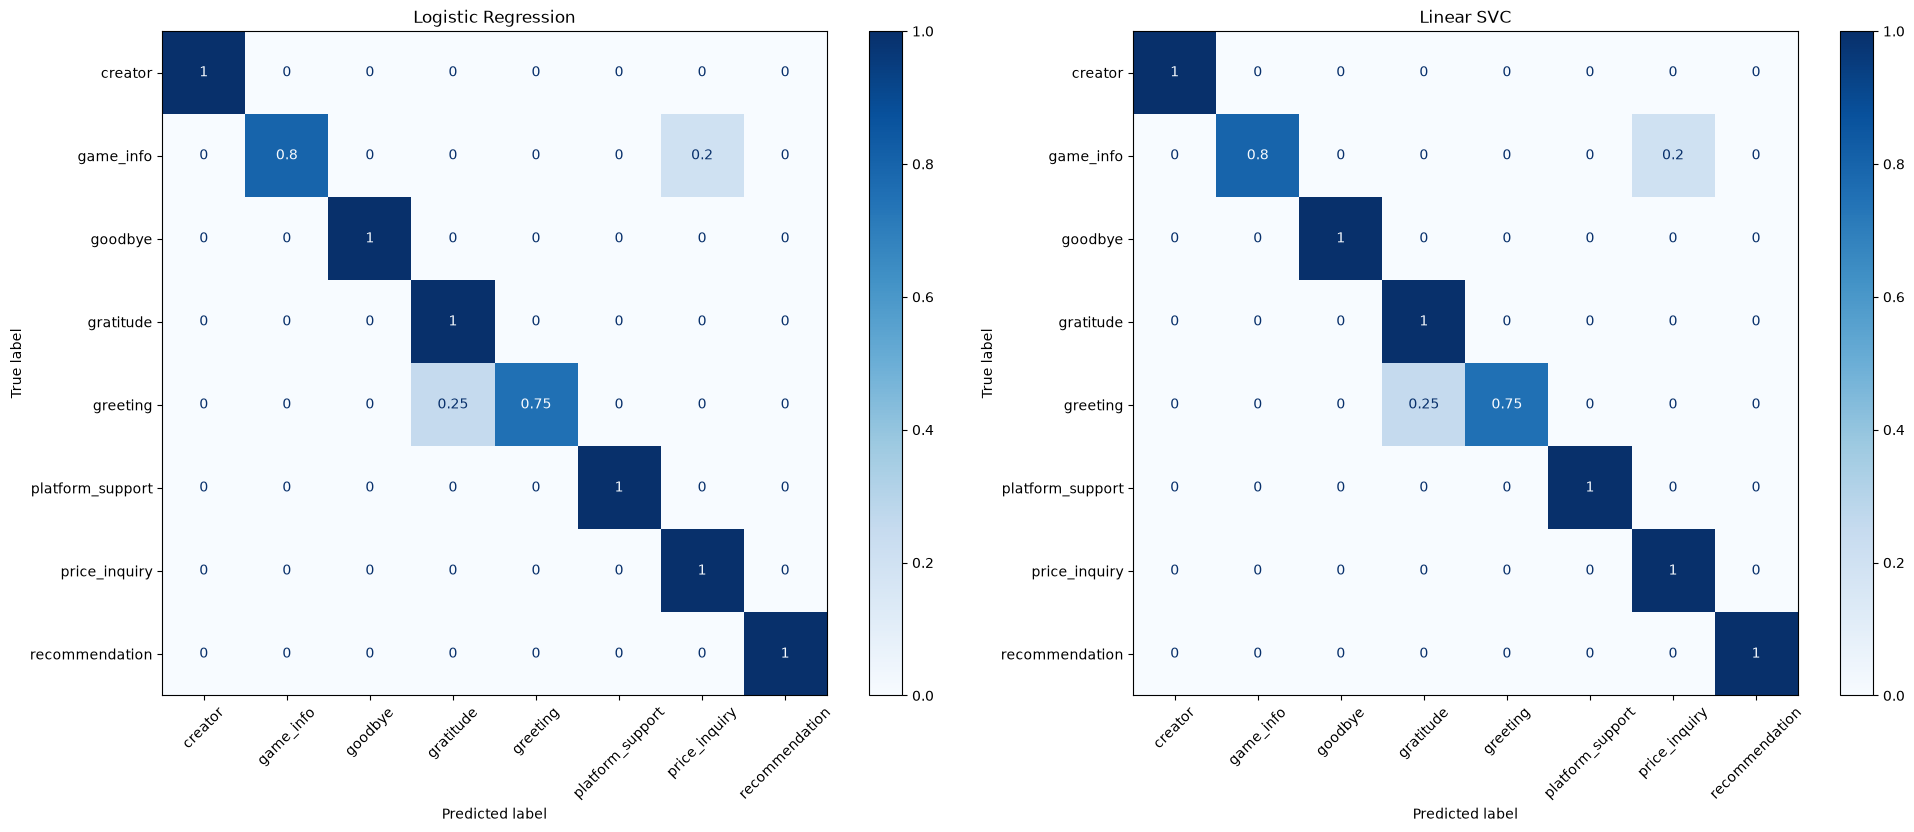

In [17]:
print("Logistic Regression:")
print(classification_report(y_test, lr_pred, zero_division=0))

print("LinearSVC:")
print(classification_report(y_test, lsvc_pred, zero_division=0))

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    labels=sorted(set(y_test)),
    normalize="true",
    ax=ax[0],
    xticks_rotation=45,
    cmap="Blues",
)

ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lsvc_pred,
    labels=sorted(set(y_test)),
    normalize="true",
    ax=ax[1],
    xticks_rotation=45,
    cmap="Blues",
)

ax[1].set_title("Linear SVC")

plt.tight_layout()
plt.show()